# Project-1

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats.mstats import winsorize
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# LOAD DATA

In [32]:
df = pd.read_csv("Dataset for Data Analytics - Sheet1.csv")

print("DATASET OVERVIEW")
print("\n")
print(df.head())
print("\nShape:", df.shape)

print("\nData Types")
print(df.dtypes)

print("\nDescriptive Statistics")
print(df.describe(include="all"))



DATASET OVERVIEW


     OrderID        Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000  2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001  2024-08-23     C75739    Phone         2     151.35   
2  ORD200002  2024-02-27     C81728   Tablet         5     550.68   
3  ORD200003  2023-10-15     C33540    Chair         1     273.19   
4  ORD200004  2025-05-08     C81840  Printer         4     626.01   

  ShippingAddress PaymentMethod OrderStatus TrackingNumber  ItemsInCart  \
0     928 Main St    Debit Card     Shipped    TRK37947903            7   
1     823 Main St        Online     Shipped    TRK91186779            3   
2     512 Main St   Credit Card   Cancelled    TRK42903982            8   
3     275 Main St    Debit Card    Returned    TRK62788070            5   
4     668 Main St        Online   Delivered    TRK29241424            8   

  CouponCode ReferralSource  TotalPrice  
0     SAVE10      Instagram     2853.10  
1     SAVE10       Referral    

# DATA UNDERSTANDING

In [33]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical Features")
print(numerical_cols)

print("\nCategorical Features")
print(categorical_cols)



Numerical Features
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']

Categorical Features
['OrderID', 'Date', 'CustomerID', 'Product', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'CouponCode', 'ReferralSource']


# MISSING VALUE ANALYSIS

In [34]:
print("\nMissing Values")
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "MissingCount": missing,
    "MissingPercent": (missing / len(df)) * 100
})

print(missing_df.sort_values("MissingPercent", ascending=False))
print("\n")
# CouponCode business imputation

if "CouponCode" in df.columns:
    df["CouponCode"] = df["CouponCode"].fillna("NoCoupon")
df


Missing Values
                 MissingCount  MissingPercent
CouponCode                309           25.75
OrderID                     0            0.00
CustomerID                  0            0.00
Product                     0            0.00
Quantity                    0            0.00
Date                        0            0.00
UnitPrice                   0            0.00
ShippingAddress             0            0.00
OrderStatus                 0            0.00
PaymentMethod               0            0.00
TrackingNumber              0            0.00
ItemsInCart                 0            0.00
ReferralSource              0            0.00
TotalPrice                  0            0.00




,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NoCoupon,Facebook,1325.06
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08


# DATE FEATURES

In [35]:
df["Date"] = pd.to_datetime(df["Date"])

df["OrderMonth"] = df["Date"].dt.month
df["OrderQuarter"] = df["Date"].dt.quarter
df["OrderYear"] = df["Date"].dt.year
df["DayOfWeek"] = df["Date"].dt.day_name()

df["WeekendPurchaseFlag"] = (
    df["Date"].dt.weekday >= 5
).astype(int)


def season_mapper(month):

    if month in [12, 1, 2]:
        return "Winter"

    if month in [3, 4, 5]:
        return "Spring"

    if month in [6, 7, 8]:
        return "Summer"

    return "Autumn"


df["SeasonalPurchase"] = (
    df["OrderMonth"]
    .apply(season_mapper)
)
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,OrderMonth,OrderQuarter,OrderYear,DayOfWeek,WeekendPurchaseFlag,SeasonalPurchase
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,1,2023,Wednesday,0,Winter
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,3,2024,Friday,0,Summer
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,1,2024,Tuesday,0,Winter
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,4,2023,Sunday,1,Autumn
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,2,2025,Thursday,0,Spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,6,FREESHIP,Google,107.04,6,2,2024,Thursday,0,Summer
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,5,NoCoupon,Facebook,1325.06,3,1,2024,Monday,0,Spring
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,2,FREESHIP,Instagram,873.68,7,3,2023,Thursday,0,Summer
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,4,WINTER15,Instagram,1050.08,8,3,2024,Thursday,0,Summer


# OUTLIER ANALYSIS

In [36]:
def detect_iqr_outliers(series):

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (series < lower) | (series > upper)

    return mask, lower, upper


In [37]:
def detect_zscore_outliers(series):

    z = np.abs(stats.zscore(series))

    return z > 3
outlier_summary = {}

In [38]:
for col in numerical_cols:

    iqr_mask, lower, upper = detect_iqr_outliers(df[col])

    z_mask = detect_zscore_outliers(df[col])

    outlier_summary[col] = {
        "IQR_Outliers": int(iqr_mask.sum()),
        "ZScore_Outliers": int(z_mask.sum())
    }

print("\nOutlier Summary")
print(pd.DataFrame(outlier_summary).T)


Outlier Summary
             IQR_Outliers  ZScore_Outliers
Quantity                0                0
UnitPrice               0                0
ItemsInCart             0                0
TotalPrice              8                0


In [59]:
for col in numerical_cols:

    df[col] = winsorize(
        df[col],
        limits=[0.01, 0.01]
    ).data

# CUSTOMER SPENDING FEATURES

In [60]:
df["AvgPricePerItem"] = (
    df["TotalPrice"] / df["Quantity"]
)

df["RevenuePerCartItem"] = (
    df["TotalPrice"] / df["ItemsInCart"]
)

df["PurchaseIntensityScore"] = (
    df["Quantity"] * df["ItemsInCart"]
)

df["SpendingCategory"] = pd.qcut(
    df["TotalPrice"],
    q=3,
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

# CART INTELLIGENCE

In [61]:
df["CartEfficiency"] = (
    df["TotalPrice"] / df["ItemsInCart"]
)

df["HighCartValueFlag"] = (
    df["TotalPrice"]
    > df["TotalPrice"].quantile(0.75)
).astype(int)

df["QuantityPerCartRatio"] = (
    df["Quantity"] / df["ItemsInCart"]
)

# COUPON INTELLIGENCE

In [62]:
df["DiscountUsed"] = (
    df["CouponCode"] != "NoCoupon"
).astype(int)

df["CouponEffectivenessScore"] = (
    df["DiscountUsed"] *
    df["RevenuePerCartItem"]
)

# BUSINESS FEATURES

In [63]:
total_revenue = df["TotalPrice"].sum()

df["RevenueContributionScore"] = (
    df["TotalPrice"] / total_revenue
)

customer_orders = (
    df.groupby("CustomerID")
    .size()
)

df["PurchaseFrequencyProxy"] = (
    df["CustomerID"]
    .map(customer_orders)
)

# Customer Value Index

scaler = MinMaxScaler()

temp = pd.DataFrame({
    "Revenue": scaler.fit_transform(
        df[["TotalPrice"]]
    ).flatten(),

    "Quantity": scaler.fit_transform(
        df[["Quantity"]]
    ).flatten(),

    "Cart": scaler.fit_transform(
        df[["ItemsInCart"]]
    ).flatten()
})

df["CustomerValueIndex"] = (
    temp.mean(axis=1)
)
df

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,SpendingCategory,CartEfficiency,HighCartValueFlag,QuantityPerCartRatio,DiscountUsed,CouponEffectivenessScore,RevenueContributionScore,PurchaseFrequencyProxy,CustomerValueIndex,CustomerSegment
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,...,High,407.585714,1,0.714286,1,407.585714,0.002257,1,0.845215,VIP
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,...,Low,100.900000,0,0.666667,1,100.900000,0.000239,1,0.184770,Low Value
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,...,High,344.175000,1,0.625000,1,344.175000,0.002178,1,0.871999,VIP
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,...,Low,54.638000,0,0.200000,1,54.638000,0.000216,1,0.172475,Low Value
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,...,High,313.005000,1,0.500000,1,313.005000,0.001981,1,0.763020,VIP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,ORD201195,2024-06-20,C21126,Desk,1,107.04,392 Main St,Credit Card,Cancelled,TRK38009181,...,Low,17.840000,0,0.166667,1,17.840000,0.000085,1,0.192424,Low Value
1196,ORD201196,2024-03-04,C20095,Monitor,2,662.53,778 Main St,Online,Cancelled,TRK69207593,...,High,265.012000,0,0.400000,0,0.000000,0.001048,1,0.363989,Medium Value
1197,ORD201197,2023-07-13,C79674,Tablet,2,436.84,275 Main St,Online,Delivered,TRK88039356,...,Medium,436.840000,0,1.000000,1,436.840000,0.000691,1,0.206455,Low Value
1198,ORD201198,2024-08-22,C64753,Chair,4,262.52,509 Main St,Debit Card,Cancelled,TRK71683331,...,Medium,262.520000,0,1.000000,1,262.520000,0.000831,1,0.465338,High Value


# UNIVARIATE ANALYSIS

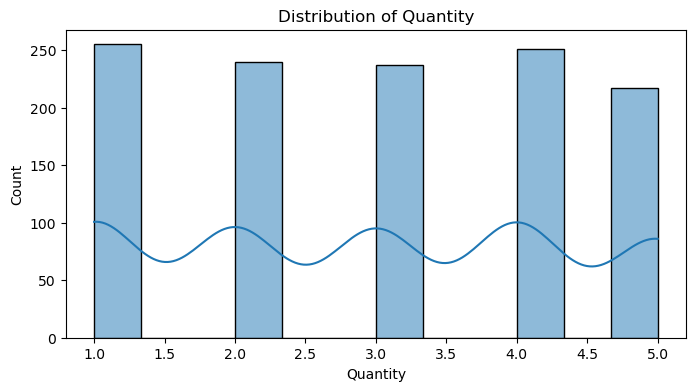

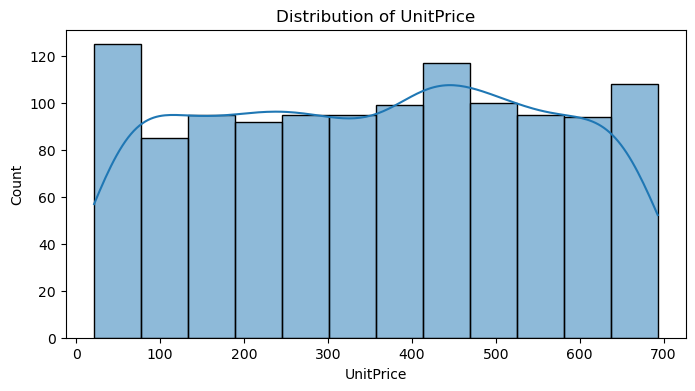

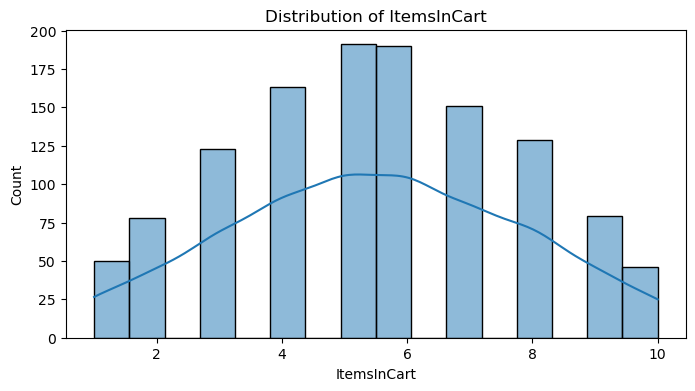

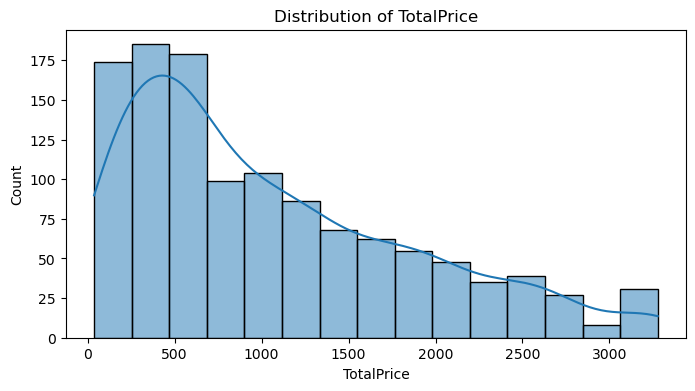

In [64]:
for col in numerical_cols:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.show()

# BOXPLOTS

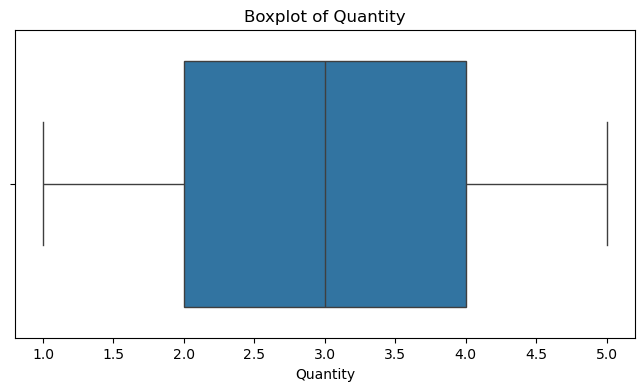

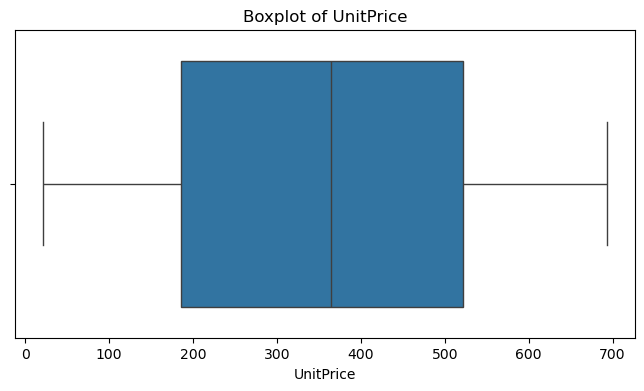

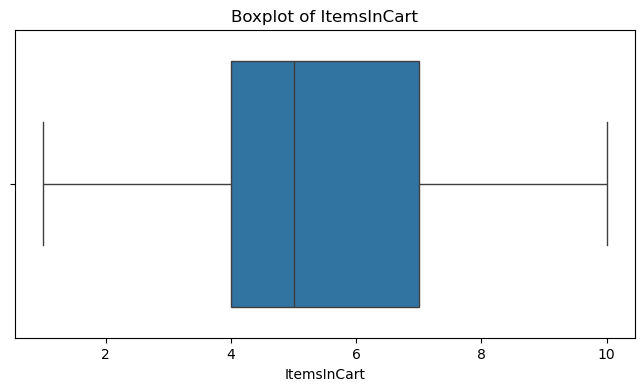

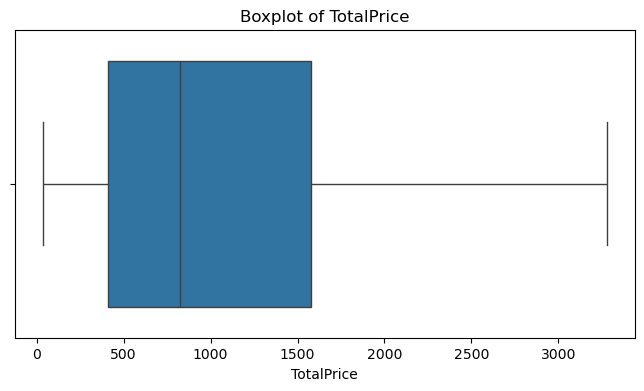

In [65]:
for col in numerical_cols:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")
    plt.show()

# CORRELATION

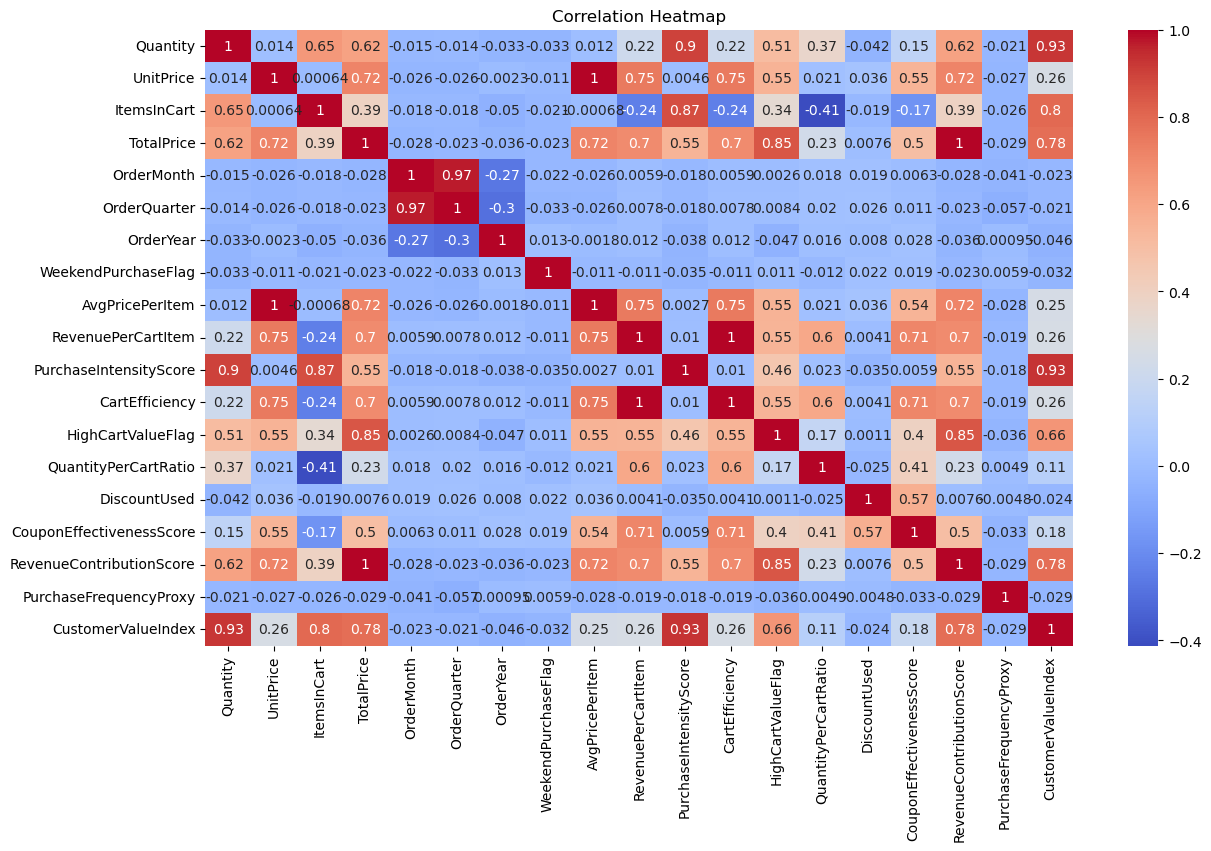

In [66]:
corr_cols = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    corr_cols.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# MONTHLY SALES TREND

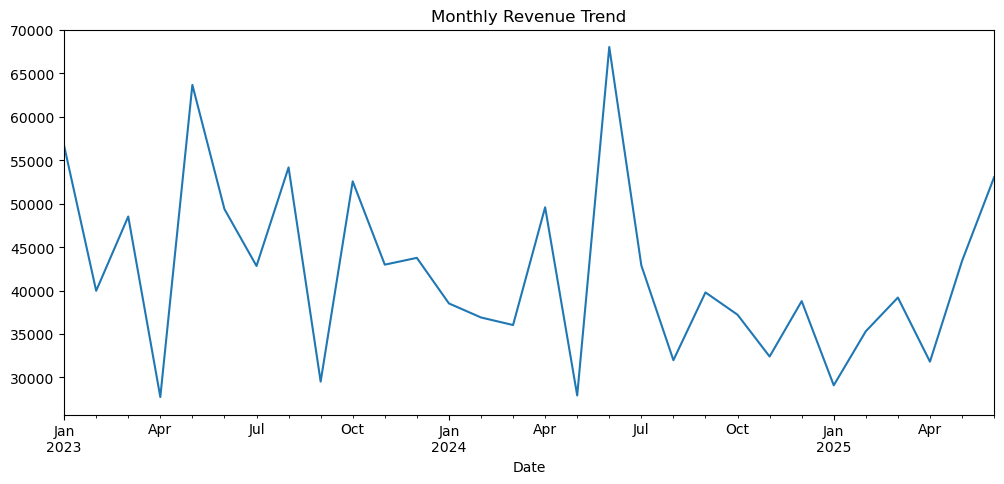

In [67]:
monthly_sales = (
    df.groupby(
        pd.Grouper(
            key="Date",
            freq="ME"
        )
    )["TotalPrice"]
    .sum()
)

plt.figure(figsize=(12, 5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")

plt.show()

# COUPON TREND

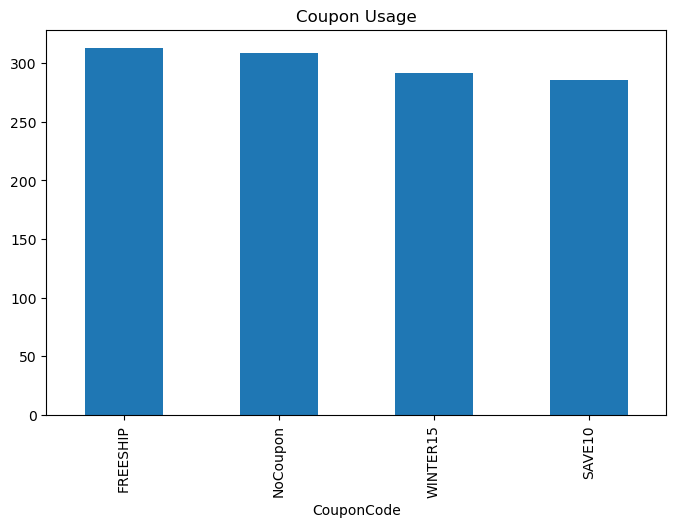

In [68]:
plt.figure(figsize=(8, 5))

df["CouponCode"].value_counts().plot(
    kind="bar"
)

plt.title("Coupon Usage")

plt.show()

# PAYMENT METHOD ANALYSIS

In [69]:
payment_summary = (
    df.groupby("PaymentMethod")
    .agg(
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        AvgOrderValue=("TotalPrice", "mean")
    )
)

print(payment_summary)

               Orders    Revenue  AvgOrderValue
PaymentMethod                                  
Cash              246  259748.23    1055.887114
Credit Card       234  263854.93    1127.585171
Debit Card        232  232248.54    1001.071293
Gift Card         230  246069.41    1069.867000
Online            258  262084.84    1015.832713


# REFERRAL SOURCE ANALYSIS

In [70]:
referral_summary = (
    df.groupby("ReferralSource")
    .agg(
        Revenue=("TotalPrice", "sum"),
        Orders=("OrderID", "count")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

print(referral_summary)

                  Revenue  Orders
ReferralSource                   
Instagram       275220.35     259
Email           261644.94     250
Google          250370.60     241
Facebook        249988.14     228
Referral        226781.92     222


# PRODUCT ANALYSIS

In [71]:
product_summary = (
    df.groupby("Product")
    .agg(
        Revenue=("TotalPrice", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

print(product_summary.head(10))

           Revenue  Quantity
Product                     
Chair    195532.87       562
Printer  195465.07       542
Laptop   191905.06       535
Tablet   186357.50       497
Monitor  175550.38       480
Desk     167469.63       508
Phone    151725.44       411


# CUSTOMER SEGMENTATION

In [72]:
df["CustomerSegment"] = pd.qcut(
    df["CustomerValueIndex"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "VIP"
    ]
)

print(
    df["CustomerSegment"]
    .value_counts()
)

CustomerSegment
Low Value       300
Medium Value    300
High Value      300
VIP             300
Name: count, dtype: int64


# REVENUE BY SEASON

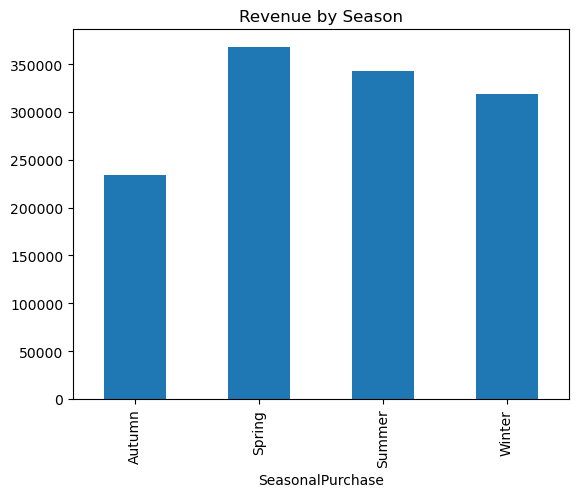

In [73]:
season_revenue = (
    df.groupby(
        "SeasonalPurchase"
    )["TotalPrice"]
    .sum()
)

season_revenue.plot(
    kind="bar"
)

plt.title(
    "Revenue by Season"
)

plt.show()

# SAVE CLEAN DATA

In [74]:
df.to_csv(
    "engineered_features.csv",
    index=False
)

print("\\nProject Completed Successfully")

\nProject Completed Successfully
